# UC2 · 02 — Time-resolved heterogeneous queries

Every query below joins several layers of the one graph built in `01`. Because
the second aspect is *time*, the same join evaluated layer by layer also shows
*when* a pattern appears — with no per-timepoint bookkeeping of separate tables.

Two things are unpacked from the graph on reload and used throughout:
`G.edge_definitions` gives each binary edge its endpoints as real
`(vertex_id, (mechanism, time))` tuples, and `G.hyperedge_definitions` gives
each complex its subunit set.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import annnet as an

DATA, TABLES, FIGS = Path("data"), Path("outputs/tables"), Path("outputs/figures")
TIMES = ("1h", "12h", "24h", "48h", "72h", "96h")

G = an.AnnNet.read(str(DATA / "uc2.annnet"))

edge_kind = G.attrs.get_attr_from_edges("edge_kind")
E = pd.DataFrame(
    [(e, s[0], *s[1], t[0], *t[1], edge_kind[e]) for e, (s, t, _) in G.edge_definitions.items()],
    columns=["edge_id", "src", "src_mech", "src_time", "tgt", "tgt_mech", "tgt_time", "edge_kind"],
)
intra = E[(E.src_mech == E.tgt_mech) & (E.src_time == E.tgt_time)]

subunits = {
    e: {m[0].removeprefix("prot:") for m in spec["members"]}
    for e, spec in G.hyperedge_definitions.items()
    if str(e).startswith("cpx:")
}

print(E.edge_kind.value_counts().to_string())
print(f"\nintra-layer {len(intra):,} (both endpoints in one (mechanism, time) layer)")
print(f"interlayer  {len(E) - len(intra):,} (the two coupling families)")
print(f"complexes   {len(subunits):,} hyperedges")

edge_kind
signaling               26330
regulatory              10162
coupling_time            7660
coupling_translation     3322

intra-layer 36,492 (both endpoints in one (mechanism, time) layer)
interlayer  10,982 (the two coupling families)
complexes   3,446 hyperedges


## How the response grows

`layer_vertex_set` reads a node-layer population straight off the graph.

     signaling_V  signaling_E  regulatory_V  regulatory_E
1h           107          137           116           158
12h          815         1732           513           838
24h         1131         2668           750          1346
48h         1651         4885          1063          2044
72h         1955         5988          1221          2184
96h         2984        10920          1840          3592


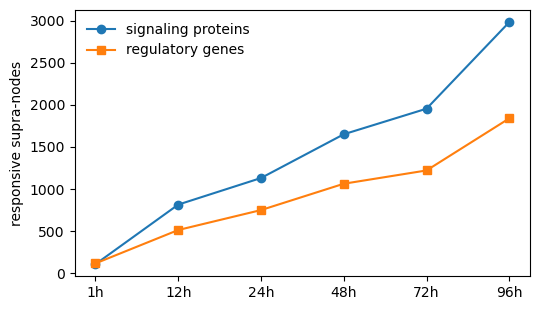

In [2]:
topology = pd.DataFrame(
    {
        "signaling_V": [len(G.layers.layer_vertex_set(("signaling", t))) for t in TIMES],
        "signaling_E": [len(intra[(intra.edge_kind == "signaling") & (intra.src_time == t)]) for t in TIMES],
        "regulatory_V": [len(G.layers.layer_vertex_set(("regulatory", t))) for t in TIMES],
        "regulatory_E": [len(intra[(intra.edge_kind == "regulatory") & (intra.src_time == t)]) for t in TIMES],
    },
    index=list(TIMES),
)
topology.to_csv(TABLES / "per_time_topology.csv")
print(topology.to_string())

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(TIMES, topology.signaling_V, "o-", label="signaling proteins")
ax.plot(TIMES, topology.regulatory_V, "s-", label="regulatory genes")
ax.set_ylabel("responsive supra-nodes")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGS / "per_time_topology.png", dpi=150)
plt.show()

## Q1 — When do transcription factors co-regulate complex assembly?

Three layers at once: complex hyperedges (protein ∈ complex, at `0h`),
translation coupling (gene → protein), and regulatory edges (TF → target). A
(TF, complex) pair is kept when the TF's targets *responsive at t* cover at
least half the complex's subunits. Evaluating it per layer turns a static query
into a temporal one for free.

In [3]:
MIN_FRACTION, MIN_HITS = 0.5, 2

regulatory = intra[intra.edge_kind == "regulatory"]


def coregulated_at(t):
    """(TF, complex) pairs passing the coverage rule using only layer-`t` edges."""
    layer = regulatory[regulatory.src_time == t]
    targets_of = (
        layer.assign(
            tf=layer.src.str.removeprefix("gene:"), target=layer.tgt.str.removeprefix("gene:")
        )
        .groupby("tf")["target"]
        .apply(set)
    )
    return {
        (tf, complex_id)
        for complex_id, genes in subunits.items()
        if len(genes) >= 3
        for tf, targets in targets_of.items()
        if len(genes & targets) >= MIN_HITS and len(genes & targets) / len(genes) >= MIN_FRACTION
    }


pairs_at = {t: coregulated_at(t) for t in TIMES}
print("(TF, complex) co-regulation pairs:", {t: len(p) for t, p in pairs_at.items()})

latest = pd.DataFrame(sorted(pairs_at[TIMES[-1]]), columns=["tf", "complex_id"])
latest.to_csv(TABLES / f"coregulation_{TIMES[-1]}.csv", index=False)
print(f"\nfirst {TIMES[-1]} pairs:")
print(latest.head(8).to_string(index=False))

(TF, complex) co-regulation pairs: {'1h': 3, '12h': 53, '24h': 63, '48h': 130, '72h': 132, '96h': 278}

first 96h pairs:
  tf                                                              complex_id
CUX1                                          cpx:ECT2-KIF23-RACGAP1 complex
E2F1 cpx:BASC (Ab 81) complex (BRCA1-associated genome surveillance complex)
E2F1                                                     cpx:BRCA1 A complex
E2F1                                                     cpx:BRCA1 C complex
E2F1                                               cpx:BVR-PKCD-ERK2 complex
E2F1                                             cpx:CDC2-CCNA2-CDK2 complex
E2F1                                       cpx:CDKN1A-TP53-CDK1-PCNA complex
E2F1                                      cpx:CyclinD3-CDK4-CDK6-p21 complex


## Q2 — Cross-compartment signaling, per timepoint

The organelle membership is read back out of the slices created in `01` — the
slices are the storage, not a side table. An edge is cross-compartment when its
two endpoints belong to different organelle slices.

In [4]:
organelle = {
    v: name
    for name in G.slices.list(include_default=False)
    if G.attrs.get_slice_attr(name, "role") == "organelle"
    for v in G.slices.vertices(name)
}
print(f"{len(set(organelle.values()))} organelle slices covering {len(organelle):,} proteins\n")

signaling = intra[intra.edge_kind == "signaling"].assign(
    src_organelle=lambda d: d.src.map(organelle), tgt_organelle=lambda d: d.tgt.map(organelle)
)
cross = signaling[signaling.src_organelle != signaling.tgt_organelle]

per_time = pd.DataFrame(
    {
        "signaling": signaling.groupby("src_time").size().reindex(TIMES, fill_value=0),
        "cross_compartment": cross.groupby("src_time").size().reindex(TIMES, fill_value=0),
    }
)
per_time["fraction"] = (per_time.cross_compartment / per_time.signaling).round(3)
per_time.to_csv(TABLES / "cross_compartment.csv")
print(per_time.to_string())

9 organelle slices covering 9,006 proteins

          signaling  cross_compartment  fraction
src_time                                        
1h              137                 85     0.620
12h            1732               1183     0.683
24h            2668               1792     0.672
48h            4885               3162     0.647
72h            5988               3816     0.637
96h           10920               6565     0.601


## Q3 — Hub complexes

Ranks the baseline complex hyperedges by the summed signaling degree of their
subunits across every time layer — a join from a hyperedge to the binary edges
of a different aspect coordinate.

In [5]:
degree = pd.concat([signaling.src.value_counts(), signaling.tgt.value_counts()], axis=1).fillna(0).sum(axis=1)
hubs = (
    pd.DataFrame(
        [
            {
                "complex_id": complex_id,
                "n_subunits": len(genes),
                "signaling_degree": float(sum(degree.get(f"prot:{g}", 0) for g in genes)),
            }
            for complex_id, genes in subunits.items()
        ]
    )
    .sort_values("signaling_degree", ascending=False)
    .head(10)
)
hubs.to_csv(TABLES / "hub_complexes.csv", index=False)
print(hubs.head(5).to_string(index=False))

                                                                                              complex_id  n_subunits  signaling_degree
cpx:Polycystin-1 multiprotein complex (ACTN1, CDH1, SRC, JUP, VCL, CTNNB1, PXN, BCAR1, PKD1, PTK2, TLN1)          11            1799.0
                                                                             cpx:CDC2-CCNA2-CDK2 complex           3            1628.0
                                                                       cpx:CDKN1A-TP53-CDK1-PCNA complex           3            1486.0
                                                                              cpx:CDCP1-Src-EGFR complex           3            1434.0
                                                                                 cpx:CAS-SRC-FAK complex           3            1358.0
